# Лабораторная 7: генерация лиц CelebA с помощью GAN


## Метрики

Метрики считались с помощью InceptionV3 на `1000` сгенерированных изображений относительно тестовой части CelebA.

| Модель | Обучающих изображений | Эпохи | FID, ниже лучше | IS, выше лучше |
|---|---:|---:|---:|---:|
| DCGAN | 30000 | 15 | 94.75 | 2.48 +/- 0.10 |
| cDCGAN по признаку Male, инициализация из DCGAN | 30000 | 10 эпох дообучения | 267.43 | 2.72 +/- 0.04 |
| WGAN-GP | 30000 | 15 | 178.61 | 2.82 +/- 0.06 |

Условная модель имеет худший FID, но визуальное сравнение показывает, что условие `Male` влияет на сгенерированные лица. После дополнительного обучения WGAN-GP улучшила FID с `256.52` на 5-й эпохе до `178.61` на 15-й эпохе.


## Результаты DCGAN

Кривые обучения:

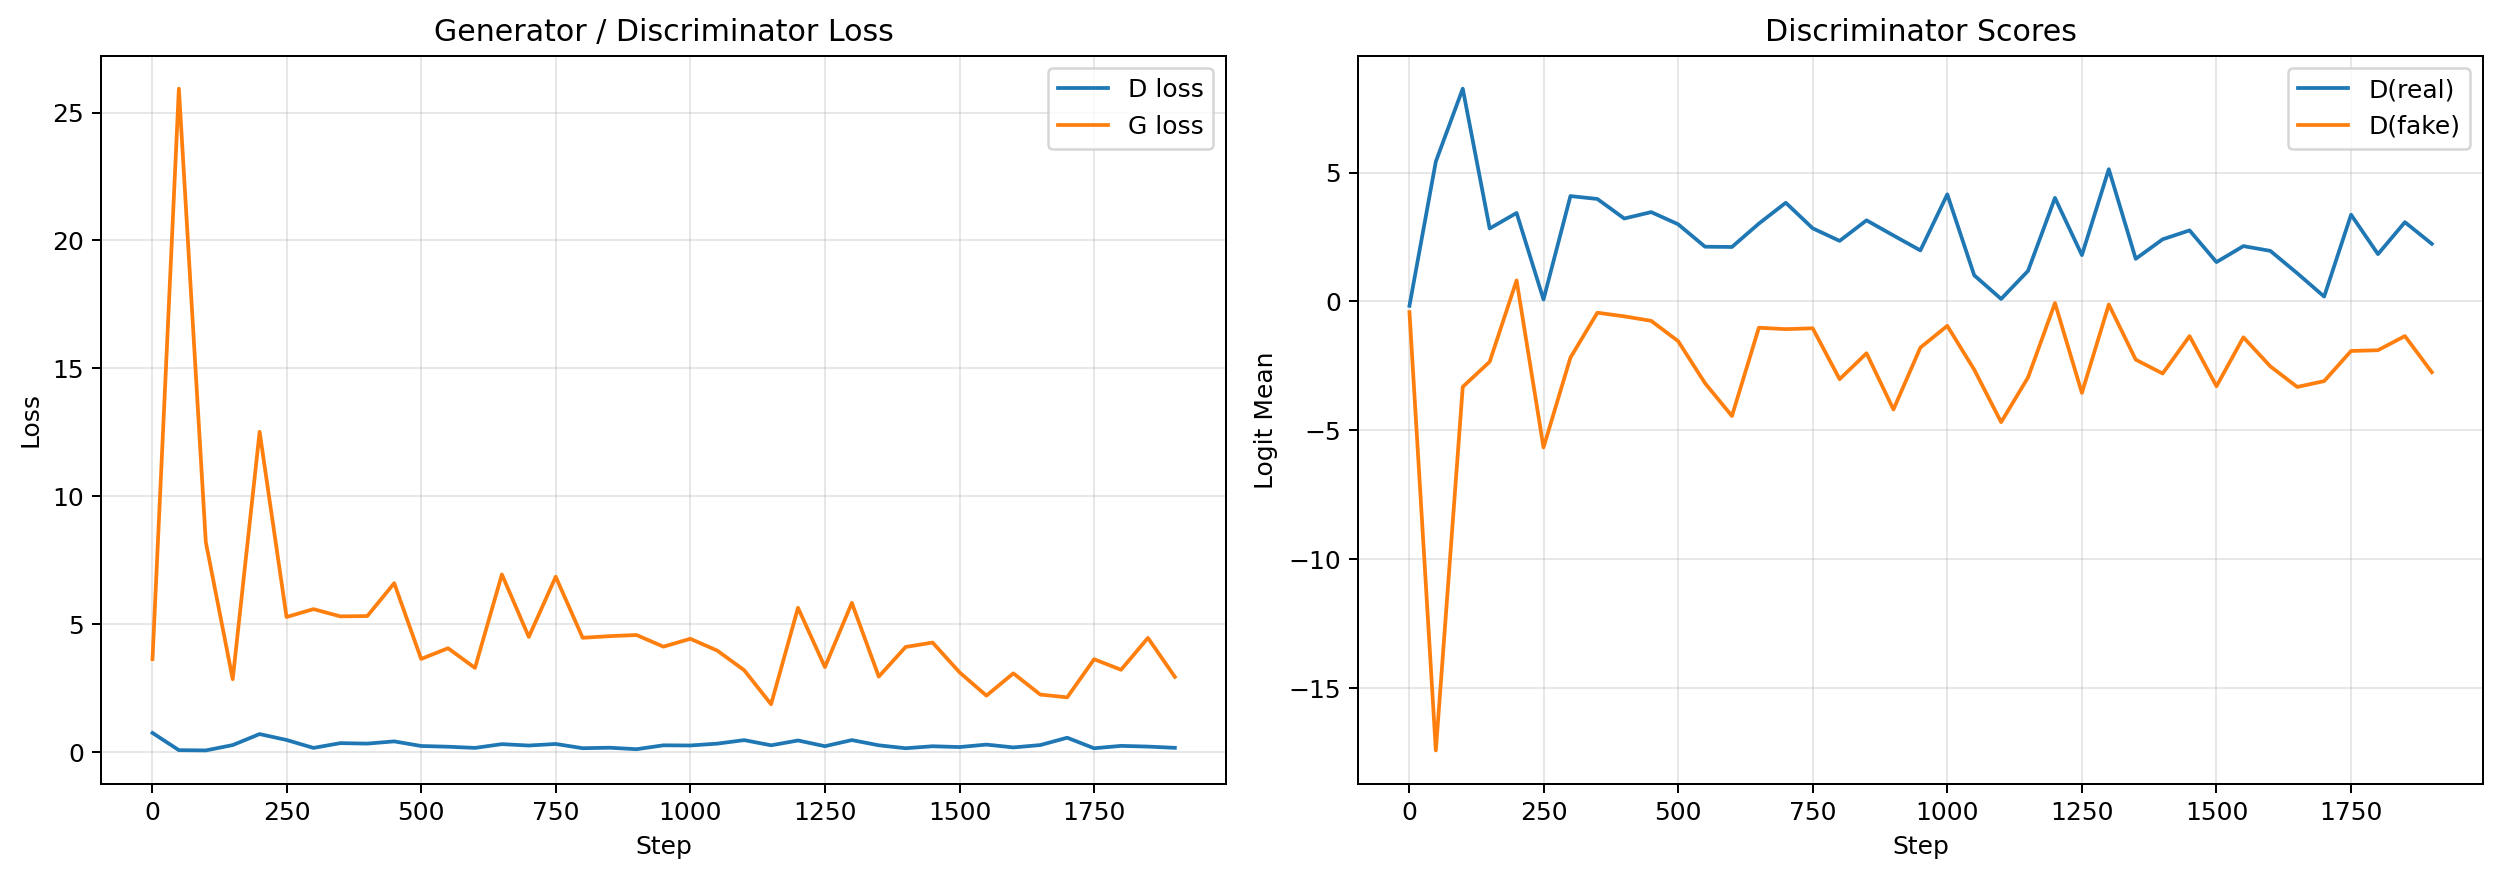

Сгенерированные лица после 15-й эпохи:

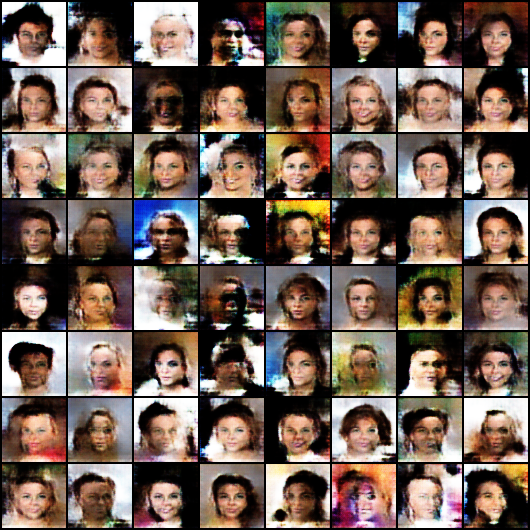


## Результаты условной DCGAN

Кривые обучения:

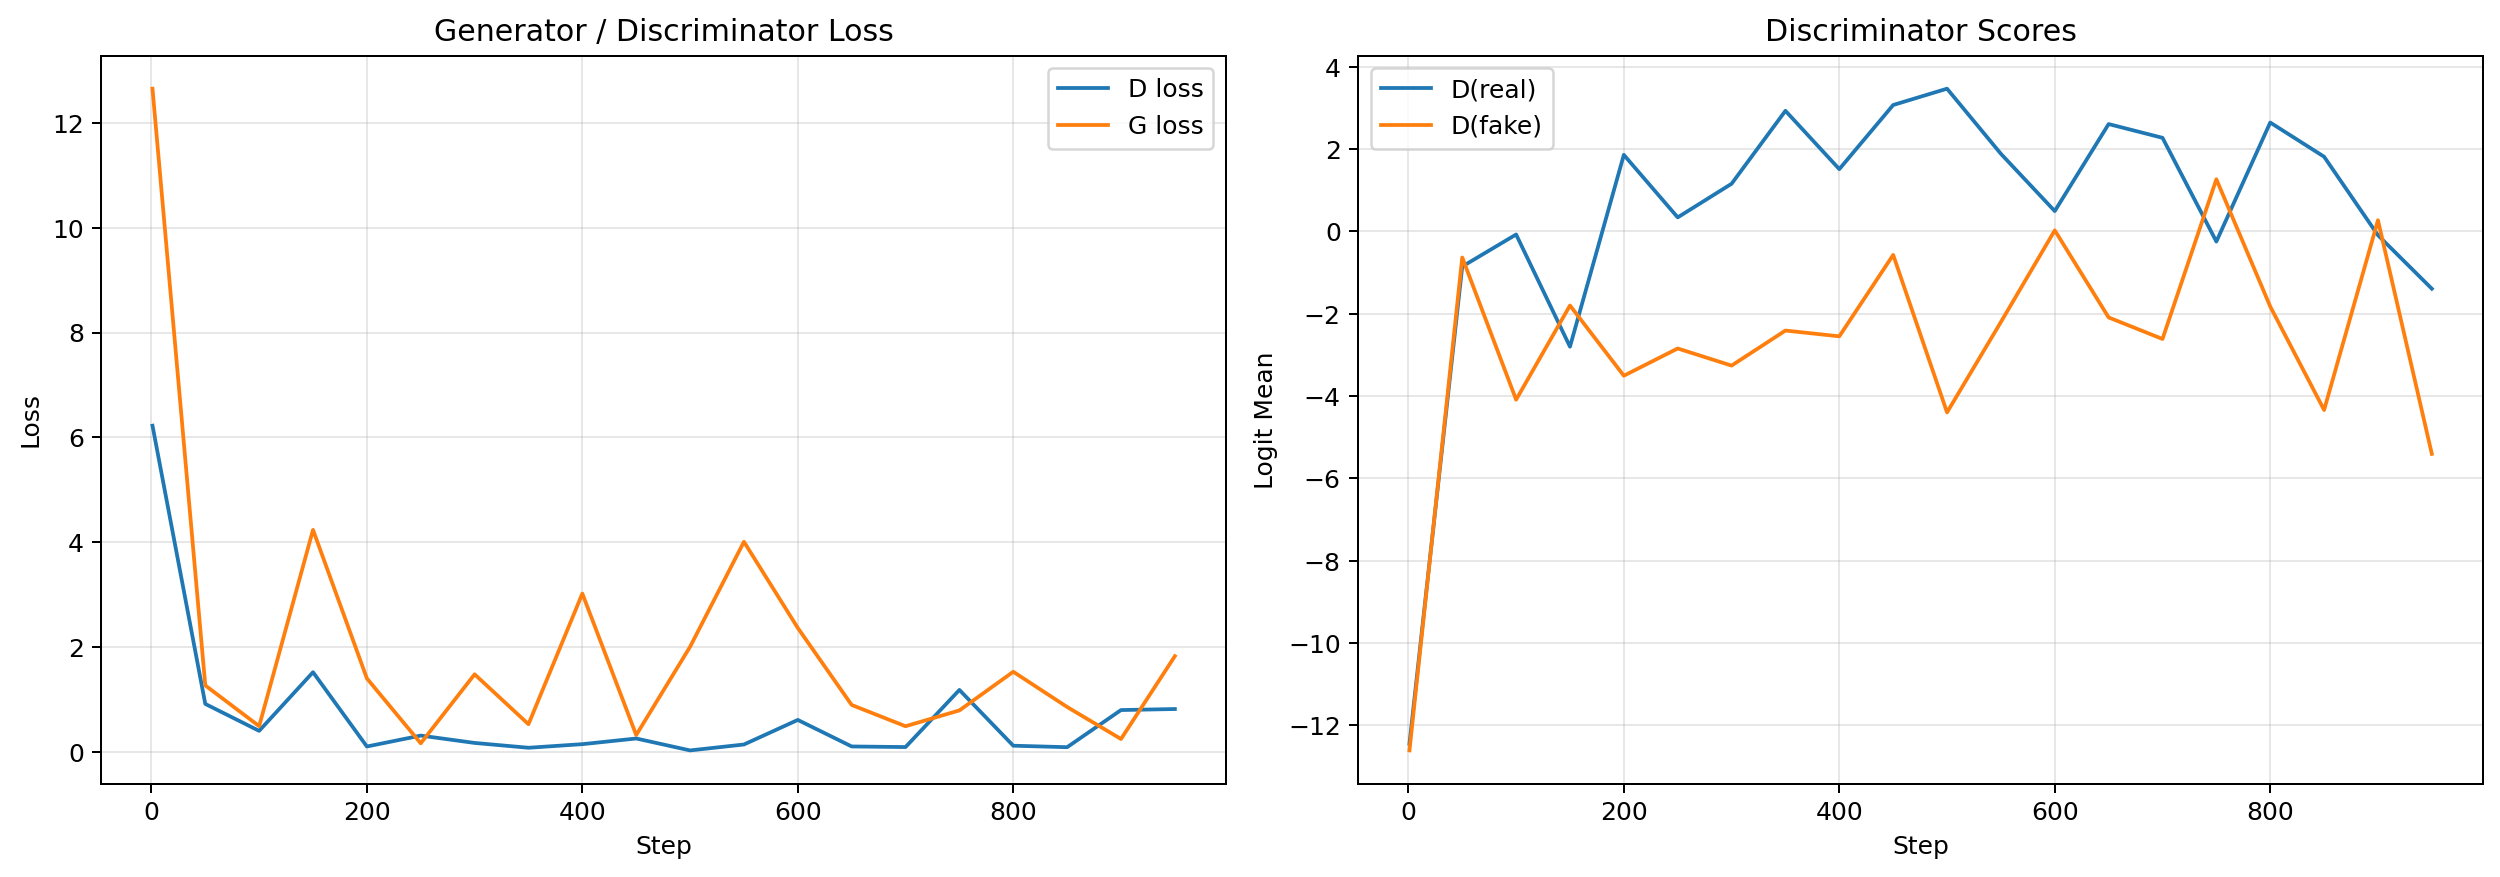

Сгенерированные лица после условного дообучения:

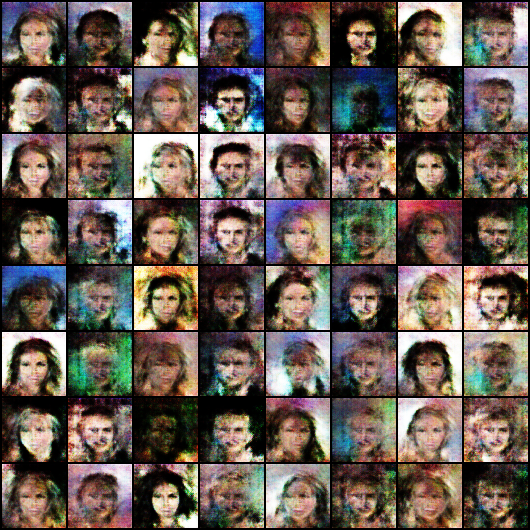

Сравнение условий: верхние 4 строки соответствуют `Male=0`, нижние 4 строки соответствуют `Male=1`.

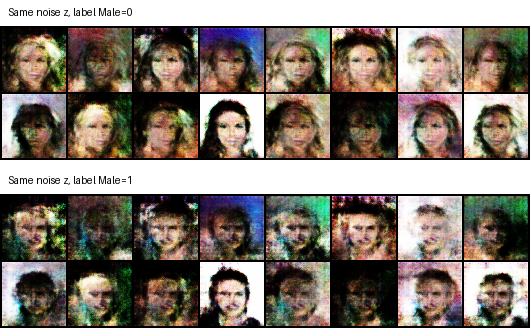

Одинаковые векторы шума, сгенерированные с разными метками. Верхний блок использует `Male=0`, нижний блок использует те же самые латентные векторы с `Male=1`.

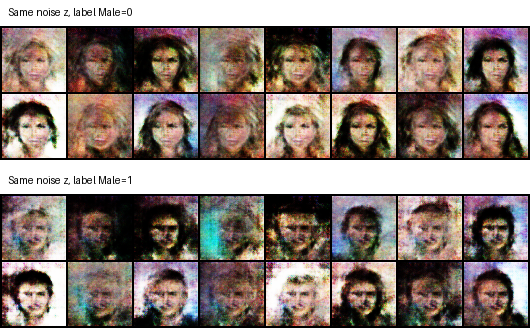


## Результаты WGAN-GP

GAN Вассерштейна использует сверточный дискриминатор без сигмоиды на выходе и функцию потерь WGAN-GP с `n_critic=3` и `lambda_gp=10`. BatchNorm был удалён из дискриминатор, а AMP отключён для этого запуска, чтобы избежать нестабильных значений градиентного штрафа.

Кривые обучения:

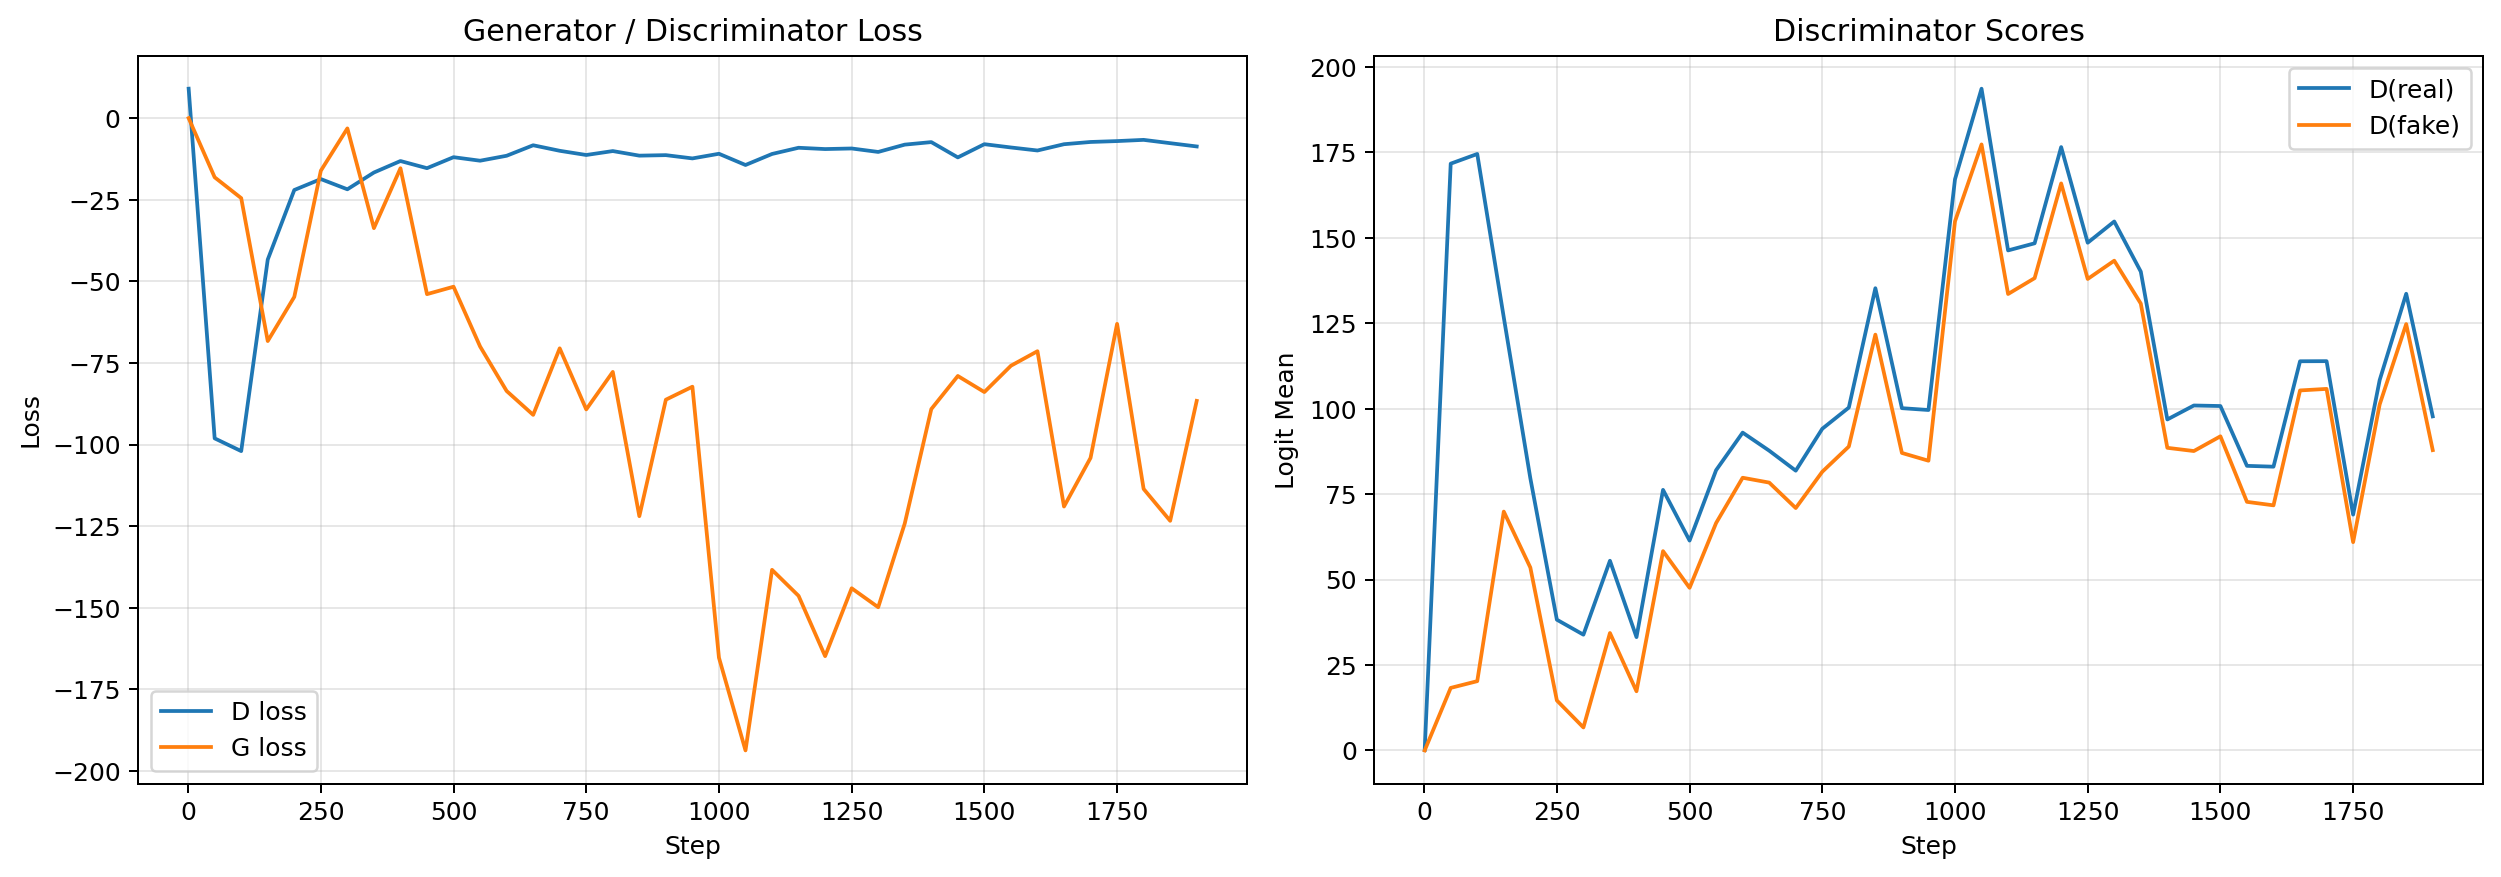

Сгенерированные лица после 15-й эпохи:

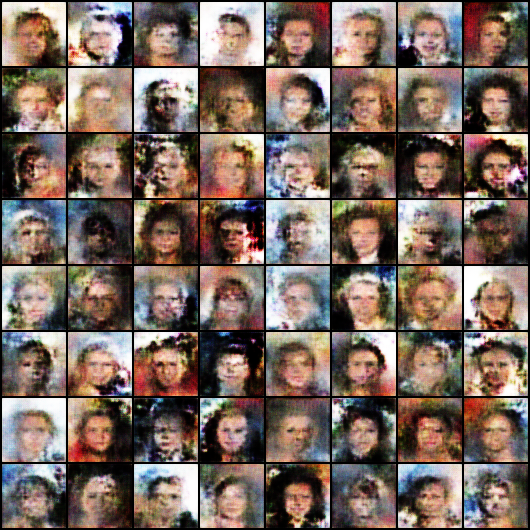


## Вывод

Самописная DCGAN после обучения на 30000 выровненных изображений лиц научилась генерировать узнаваемые лица в стиле CelebA. Условная модель использует ту же структуру сети и преобразована из безусловной DCGAN добавлением условия по метке. Сравнение для одного и того же шума показывает, что изменение только метки `Male` меняет атрибуты сгенерированного лица.

Также была обучена и оценена базовая WGAN-GP. Дополнительное обучение с 5-й до 15-й эпохи улучшило FID с `256.52` до `178.61`; визуально изображения стали больше похожи на лица, хотя всё ещё остаются более размытыми, чем у лучше дообученной DCGAN.
